In [16]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle


def parse_line_kv_only(line: str):
    result = {}
    for kv in line.split(","):
        if "=" in kv:
            k, v = kv.split("=")
            result[k] = v
    return result


def aggregate_dicts(dicts: list[dict]):
    aggregated = defaultdict(lambda: defaultdict(list))
    for d in dicts:
        key = (d["param"], d["noise_level"], d["n_pts"], d["n_indivs"])
        for k, v in d.items():
            if k not in {"param", "noise_level", "n_pts", "n_indivs"}:
                aggregated[key][k].append(v)
    return dict(aggregated)


def enhanced_plot_heatmap(
    heatmap,
    x_labels,
    y_labels,
    title,
    log_scale=True,
    cmap="viridis",
    vmin=None,
    vmax=None,
    highlight_thresh=None,
    save_fname=None,
):
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor("white")

    # Choose normalization
    norm = (
        LogNorm(
            vmin=vmin or np.nanmin(heatmap[np.nonzero(heatmap)]),
            vmax=vmax or np.nanmax(heatmap),
        )
        if log_scale
        else None
    )

    # Plot heatmap
    cax = ax.imshow(heatmap, cmap=cmap, aspect="auto", norm=norm, vmin=vmin, vmax=vmax)

    # Outer border
    ax.add_patch(
        Rectangle(
            (-0.5, -0.5),
            heatmap.shape[1],
            heatmap.shape[0],
            fill=False,
            edgecolor="black",
            linewidth=2,
        )
    )
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.5)

    # Ticks & labels
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel("n_pts")
    ax.set_ylabel("noise_level")
    ax.set_title(title, pad=12, fontsize=12, weight="bold")

    # Annotate values
    for i in range(heatmap.shape[0]):
        for j in range(heatmap.shape[1]):
            val = heatmap[i, j]
            if not np.isnan(val):
                ax.text(
                    j,
                    i,
                    f"{val:.2e}",
                    ha="center",
                    va="center",
                    color="white" if log_scale else "red",
                )

    # Draw contour based on leftmost cells per row
    if highlight_thresh is not None:
        x_positions = []
        # Iterate through every row in the heatmap
        for i in range(heatmap.shape[0]):
            row = heatmap[i, :]
            # Check ALL cells in the row (left to right)
            valid_indices = np.where((~np.isnan(row)) & (row > highlight_thresh))[0]
            if len(valid_indices) > 0:
                # Leftmost valid cell
                j = valid_indices[0]
            else:
                # No valid cell, set to right edge
                j = heatmap.shape[1]
            x = j - 0.5
            x_positions.append(x)

        # Generate contour vertices
        if x_positions:
            vertices = []
            # Start at the top edge of the first row
            vertices.append((x_positions[0], -0.5))
            for i, x in enumerate(x_positions):
                # Current row's bottom edge (y-coordinate)
                bottom_y = i + 0.5
                vertices.append((x, bottom_y))
                # Connect to the next row's position if it exists
                if i < len(x_positions) - 1:
                    next_x = x_positions[i + 1]
                    vertices.append((next_x, bottom_y))

            # Draw the contour line
            x_coords, y_coords = zip(*vertices)
            ax.plot(x_coords, y_coords, color="red", linewidth=2, linestyle="-")

    # Colorbar
    cbar = fig.colorbar(cax, ax=ax, pad=0.02)
    cbar.set_label("Median Value", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()
    if save_fname:
        fig.savefig(save_fname, dpi=300, bbox_inches="tight")


def staircase_boundary(heatmap, threshold):
    """
    This function finds the staircase boundary in a heatmap based on a threshold.
    It computes one more than the x-coordinates of the rightmost cells that
    don't exceed the threshold for each row in the heatmap, and then
    processes the x-coordinates to create a staircase-like boundary.
    """
    x_positions = []
    # Iterate through every row in the heatmap
    for i in range(heatmap.shape[0] - 1, -1, -1):
        row = heatmap[i, :]
        # Check ALL cells in the row (left to right)
        valid_indices = np.where((~np.isnan(row)) & (row <= threshold))[0]
        if len(valid_indices) > 0:
            j = 1 + valid_indices[-1]
        else:
            j = 0
        x = j - 0.5
        x_positions.append(x)

    # Generate contour vertices
    if x_positions:
        vertices = [(-0.5, -0.5 + heatmap.shape[0])]
        for i, x in enumerate(x_positions):
            if i > 0 and x < x_positions[i - 1]:
                # If the current x is less than the previous one, adjust it
                x_positions[i] = x_positions[i - 1]
                x = x_positions[i]
            # Current row's bottom edge (y-coordinate)
            bottom_y = -0.5 + heatmap.shape[0] - i
            if i == 0 and x > 0 or i > 0 and x > x_positions[i - 1]:
                vertices.append((x, bottom_y))
            vertices.append((x, bottom_y - 1))

        if x_positions[-1] < heatmap.shape[1]:
            # If the last x is less than the right edge, add it
            vertices.append((heatmap.shape[1] - 0.5, -0.5))

        # move points on the border of the heatmap slightly inwards
        diff = 0.02
        for i in range(len(vertices)):
            x, y = vertices[i]
            if x == -0.5:
                vertices[i] = (x + diff, y)
            elif x == heatmap.shape[1] - 0.5:
                vertices[i] = (x - diff, y)
            x, y = vertices[i]
            if y == -0.5:
                vertices[i] = (x, y + diff)
            elif y == heatmap.shape[0] - 0.5:
                vertices[i] = (x, y - diff)
        return vertices

    return []


def plot_heatmap_with_staircase(
    heatmap,
    x_labels,
    y_labels,
    title,
    vertices_T=None,
    vertices_C=None,
    log_scale=True,
    cmap="viridis",
    vmin=None,
    vmax=None,
    save_fig=None,
):
    """
    Plots a heatmap with optional staircase boundaries and saves the plot if save_fig is provided.

    Args:
        heatmap (ndarray): 2D array representing the heatmap data.
        x_labels (list): Labels for the x-axis.
        y_labels (list): Labels for the y-axis.
        title (str): Title of the plot.
        vertices_T (list): Vertices for the T-boundary staircase.
        vertices_C (list): Vertices for the C-boundary staircase.
        log_scale (bool): Whether to use logarithmic scaling.
        cmap (str): Colormap for the heatmap.
        vmin (float): Minimum value for the color scale.
        vmax (float): Maximum value for the color scale.
        save_fig (str): Path to save the figure. If None, the plot is not saved.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor("white")

    norm = (
        LogNorm(
            vmin=vmin or np.nanmin(heatmap[np.nonzero(heatmap)]),
            vmax=vmax or np.nanmax(heatmap),
        )
        if log_scale
        else None
    )

    # Plot heatmap
    cax = ax.imshow(heatmap, cmap=cmap, aspect="auto", norm=norm)

    # Outer border
    ax.add_patch(
        Rectangle(
            (-0.5, -0.5),
            heatmap.shape[1],
            heatmap.shape[0],
            fill=False,
            edgecolor="black",
            linewidth=1,
        )
    )
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.5)

    # Ticks & labels
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel("Number of observations")
    ax.set_ylabel("Observation coefficient of variation")
    ax.set_title(title, pad=12, fontsize=14, weight="bold")

    # Annotate values
    for i in range(heatmap.shape[0]):
        for j in range(heatmap.shape[1]):
            val = heatmap[i, j]
            if not np.isnan(val):
                ax.text(
                    j,
                    i,
                    f"{val:.2e}",
                    ha="center",
                    va="center",
                    color="white" if log_scale else "red",
                )

    # Draw the staircase boundary
    lw = 4
    if vertices_T:
        x_coords, y_coords = zip(*vertices_T)
        ax.plot(x_coords, y_coords, color="red", linewidth=lw, linestyle="-", alpha=0.7)
    if vertices_C:
        x_coords, y_coords = zip(*vertices_C)
        ax.plot(
            x_coords,
            y_coords,
            color="lightcoral",
            linewidth=lw,
            linestyle="-",
            alpha=0.7,
        )

    # Colorbar
    cbar = fig.colorbar(cax, ax=ax, pad=0.02)
    cbar.set_label("Median Value", rotation=270, labelpad=15)

    plt.tight_layout()
    if save_fig:
        fig.savefig(save_fig, dpi=300, bbox_inches="tight")
        plt.close(fig)
    plt.show()


def plot_heatmap_from_aggregated(aggregated, k, save_fname=None):
    # Extract keys
    param = list(aggregated.keys())[0][0]
    noise_levels = sorted({key[1] for key in aggregated}, key=lambda x: float(x))
    n_pts_values = sorted(
        {key[2] for key in aggregated}, key=lambda x: float(x), reverse=True
    )

    # build heatmap
    heatmap = np.full((len(noise_levels), len(n_pts_values)), np.nan)
    for i, nl in enumerate(noise_levels):
        for j, np_ in enumerate(n_pts_values):
            key = next((k_ for k_ in aggregated if k_[1] == nl and k_[2] == np_), None)
            if key and k in aggregated[key]:
                heatmap[i, j] = np.median([float(x) for x in aggregated[key][k]])

    title = f"Median heatmap for '{k}', parameter {param}"

    vertices = staircase_boundary(heatmap, threshold=0.3)
    plot_heatmap_with_staircase(heatmap, n_pts_values, noise_levels, title, vertices)

    # enhanced_plot_heatmap(
    #     heatmap,
    #     x_labels=n_pts_values,
    #     y_labels=noise_levels,
    #     title=f"Median heatmap for '{k}', parameter {param}",
    #     log_scale=True,
    #     cmap='cividis',
    #     highlight_thresh=0.3
    # )


def plot_heatmaps_from_aggregated(
    aggregated,
    save_dir=None,
    vmin_param=None,
    vmax_param=None,
    vmin_T=None,
    vmax_T=None,
    vmin_C=None,
    vmax_C=None,
    include_NR=True,
):
    """
    Plots heatmaps from aggregated data and optionally saves them to a directory.

    Args:
        aggregated (dict): Aggregated data dictionary.
        save_dir (str): Directory to save the plots. If None, plots are not saved.
        vmin_param (float): Minimum value for the parameter heatmap color scale.
        vmax_param (float): Maximum value for the parameter heatmap color scale.
        vmin_T (float): Minimum value for the T heatmap color scale.
        vmax_T (float): Maximum value for the T heatmap color scale.
        vmin_C (float): Minimum value for the C heatmap color scale.
        vmax_C (float): Maximum value for the C heatmap color scale.
        include_NR (bool): Whether to include NR outcomes.
    """
    # Extract keys
    param = list(aggregated.keys())[0][0]
    noise_levels = sorted({key[1] for key in aggregated}, key=lambda x: float(x))
    n_pts_values = sorted(
        {key[2] for key in aggregated}, key=lambda x: float(x), reverse=True
    )

    def build_heatmap(k):
        # Build heatmap
        heatmap = np.full((len(noise_levels), len(n_pts_values)), np.nan)
        for i, nl in enumerate(noise_levels):
            for j, np_ in enumerate(n_pts_values):
                key = next(
                    (k_ for k_ in aggregated if k_[1] == nl and k_[2] == np_), None
                )
                if key and k in aggregated[key]:
                    heatmap[i, j] = np.median([float(x) for x in aggregated[key][k]])
        return heatmap

    for outcome in ["CR", "NR"] if include_NR else ["CR"]:
        heatmap_T = build_heatmap(f"rms_log_{outcome}_T")
        heatmap_C = build_heatmap(f"rms_log_{outcome}_C")
        vertices_T = staircase_boundary(heatmap_T, threshold=0.3)
        vertices_C = staircase_boundary(heatmap_C, threshold=0.3)
        heatmap_param = build_heatmap(f"param_relative_err_{outcome}")

        param_descs = {
            "'l'": "lysis exponent",
            "'dC'": "max CAR T-cell kill rate",
            "'jC'": "CAR T-cell expansion rate",
            "'a'": "tumor growth rate",
            "'s'": "lysis half-saturation",
        }

        latex_param = param.replace("'", "$")
        param_no_quotes = param.replace("'", "")

        # Save plots if save_dir is specified
        plot_heatmap_with_staircase(
            heatmap_param,
            n_pts_values,
            noise_levels,
            title=f"Median relative error of estimated {latex_param} ({param_descs[param]}) for {outcome} patients",
            vertices_T=vertices_T,
            vertices_C=vertices_C,
            vmin=vmin_param,
            vmax=vmax_param,
            save_fig=(
                f"{save_dir}/relative_error_{outcome}_{param_no_quotes}.png"
                if save_dir
                else None
            ),
        )

        plot_heatmap_with_staircase(
            heatmap_T,
            n_pts_values,
            noise_levels,
            title=f"Median RMS error of $\\log(T)$ under estimated {latex_param} ({param_descs[param]}) for {outcome} patients",
            vertices_T=vertices_T,
            vmin=vmin_T,
            vmax=vmax_T,
            save_fig=(
                f"{save_dir}/rms_log_T_{outcome}_{param_no_quotes}.png"
                if save_dir
                else None
            ),
        )

        plot_heatmap_with_staircase(
            heatmap_C,
            n_pts_values,
            noise_levels,
            title=f"Median RMS error of $\\log(C)$ under estimated {latex_param} ({param_descs[param]}) for {outcome} patients",
            vertices_C=vertices_C,
            vmin=vmin_C,
            vmax=vmax_C,
            save_fig=(
                f"{save_dir}/rms_log_C_{outcome}_{param_no_quotes}.png"
                if save_dir
                else None
            ),
        )


def aggregate(param):
    with open(f"results_{param}_v2.txt", "r") as f:
        lines = [line.strip() for line in f.readlines()]
        results = [parse_line_kv_only(line) for line in lines]
        agg = aggregate_dicts(results)
    return agg


def get_cmap_bounds(params, include_NR=True):
    """
    Computes the min and max of the medians for specific keys across all values in `agg`.

    Args:
        params (list): A list of parameters to call `aggregate` on.

    Returns:
        dict: A dictionary where each key ("param_relative_err", "param_relative_err_CR", "param_relative_err_NR")
              maps to a tuple (min_median, max_median).
    """
    keys_to_check = (
        [
            "param_relative_err_CR",
            "param_relative_err_NR",
            "rms_log_CR_T",
            "rms_log_NR_T",
            "rms_log_CR_C",
            "rms_log_NR_T",
        ]
        if include_NR
        else [
            "param_relative_err_CR",
            "rms_log_CR_T",
            "rms_log_CR_C",
        ]
    )
    bounds = {key: [float("inf"), float("-inf")] for key in keys_to_check}

    for param in params:
        agg = aggregate(param)  # Call aggregate for each param
        for value in agg.values():  # Iterate over all defaultdicts in agg
            for key in keys_to_check:
                if key in value:
                    # Compute the median of the list of floats
                    medians = [float(x) for x in value[key]]
                    median_value = np.median(medians)
                    # Update the min and max for the key
                    bounds[key][0] = min(bounds[key][0], median_value)
                    bounds[key][1] = max(bounds[key][1], median_value)

    # Convert bounds to tuples
    return {key: (bounds[key][0], bounds[key][1]) for key in keys_to_check}

In [2]:
params_with_NRs = ["a", "jC", "s"]
params_without_NRs = ["l", "dC"]
all_params = params_with_NRs + params_without_NRs
cmap_bounds_with_NRs = get_cmap_bounds(params_with_NRs)
cmap_bounds_without_NRs = get_cmap_bounds(params_without_NRs)
cmap_bounds_CR_only = get_cmap_bounds(all_params, include_NR=False)
print("cmap_bounds_with_NRs:", cmap_bounds_with_NRs)
print("cmap_bounds_without_NRs:", cmap_bounds_without_NRs)

cmap_bounds_with_NRs: {'param_relative_err': (np.float64(0.0021935392414841595), np.float64(0.8260164173220117)), 'param_relative_err_CR': (np.float64(0.0021355211457009787), np.float64(0.5284314435368572)), 'param_relative_err_NR': (np.float64(0.0008661553351455933), np.float64(1.2136741961738582))}
cmap_bounds_without_NRs: {'param_relative_err': (np.float64(0.0006452169900183213), np.float64(0.09521837966209964)), 'param_relative_err_CR': (np.float64(0.0006452169900183213), np.float64(0.09521837966209964)), 'param_relative_err_NR': (np.float64(-1.0), np.float64(-1.0))}


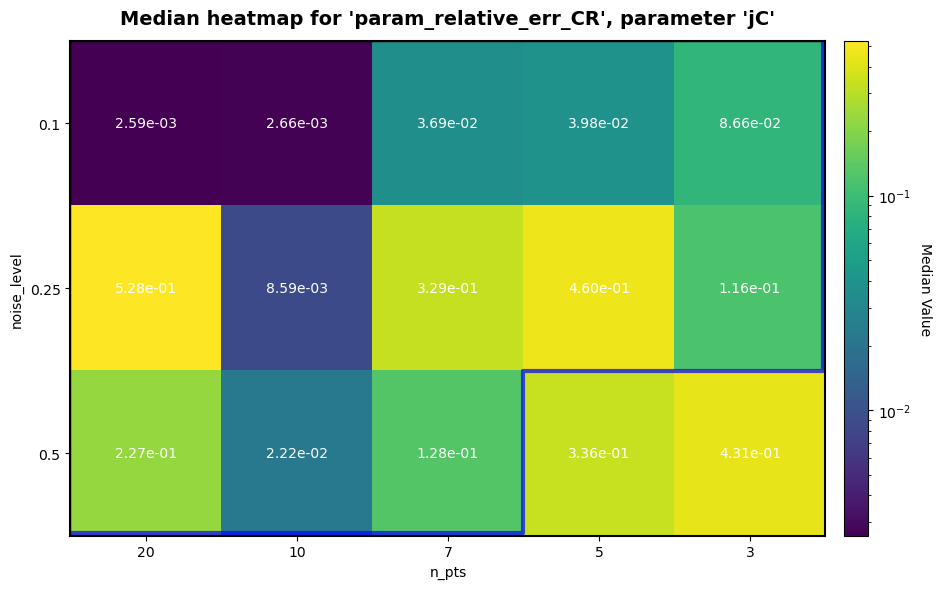

<Figure size 640x480 with 0 Axes>

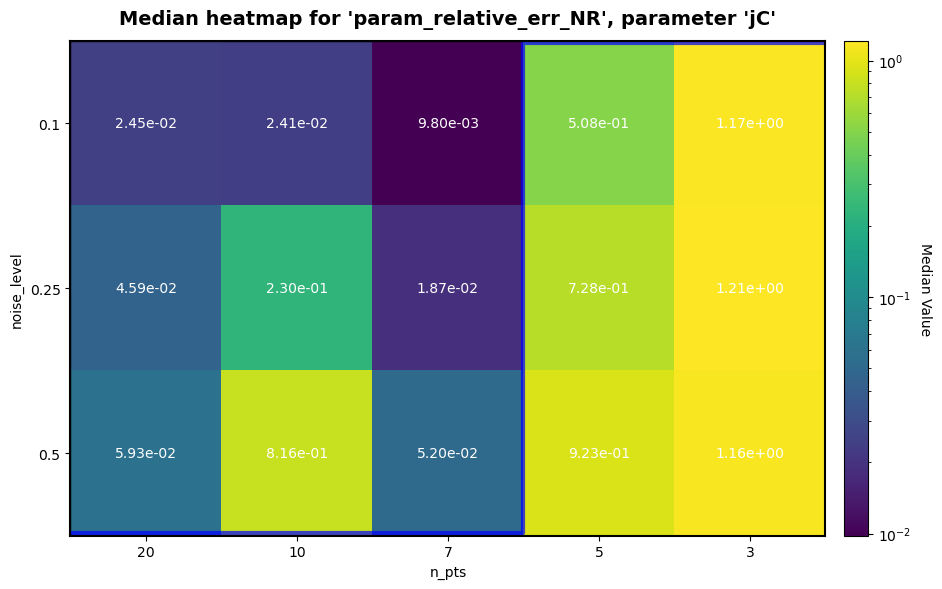

<Figure size 640x480 with 0 Axes>

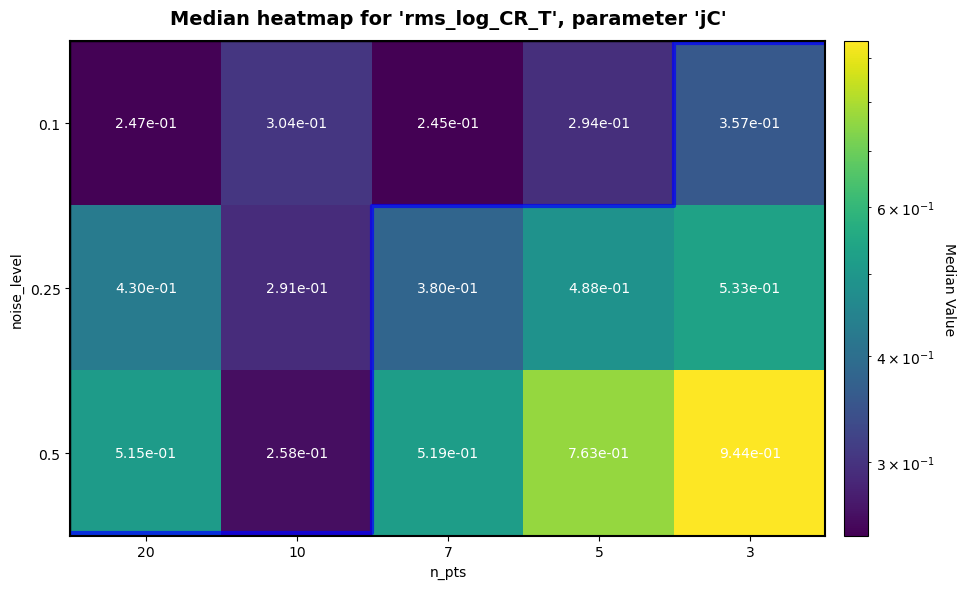

<Figure size 640x480 with 0 Axes>

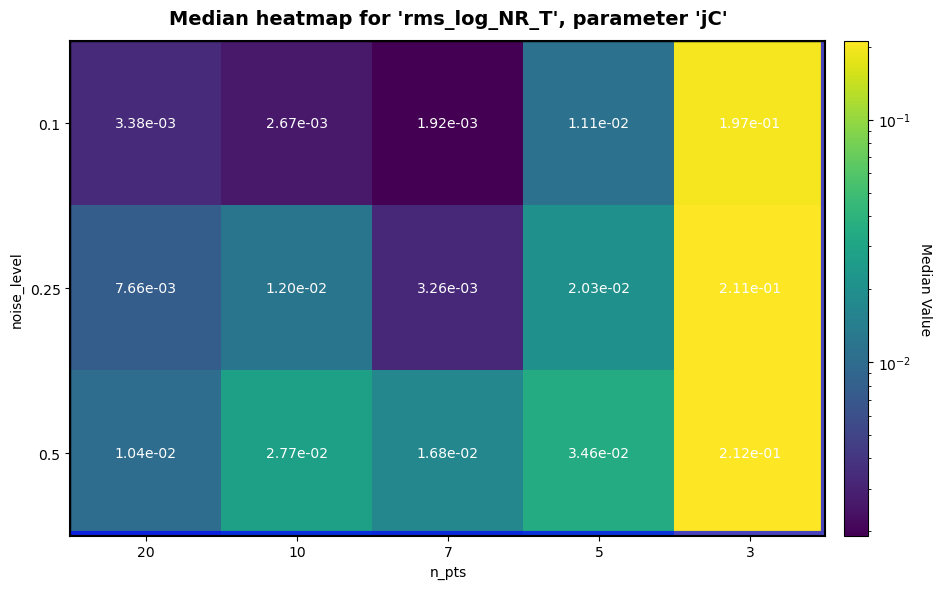

<Figure size 640x480 with 0 Axes>

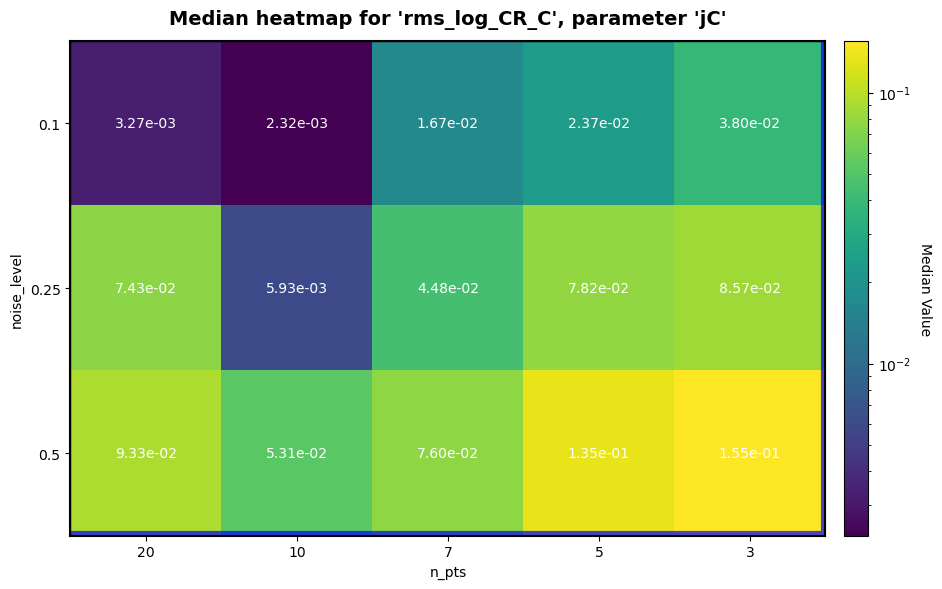

<Figure size 640x480 with 0 Axes>

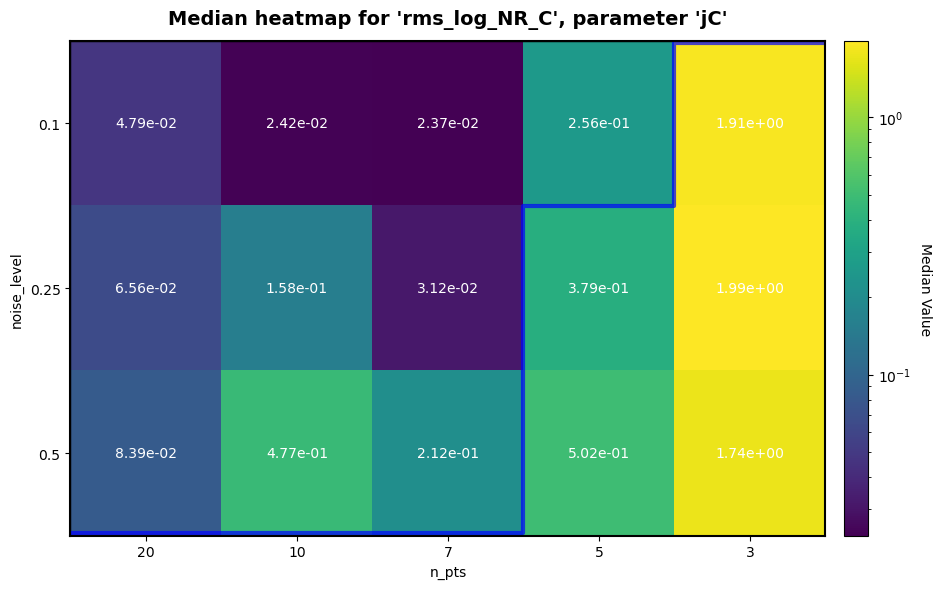

<Figure size 640x480 with 0 Axes>

In [ ]:
agg = aggregate("jC")

# for key in results[0].keys():
#     if (
#         key not in ["param", "noise_level", "n_pts", "param_seed", "noise_seed", "n_indivs"]
#         and "_M" not in key
#         and "did_converge" not in key
#     ):
#         plot_heatmap_from_aggregated(agg, key, save_fname=f"img/{key}-{param}-n_indivs=10")
for key in [
    "param_relative_err_CR",
    "param_relative_err_NR",
    "rms_log_CR_T",
    "rms_log_NR_T",
    "rms_log_CR_C",
    "rms_log_NR_C",
]:
    plot_heatmap_from_aggregated(agg, key)

In [ ]:
# plot relative err, rms log(T), rms log(C) for CR across all 5 params
params = all_params
bounds = get_cmap_bounds(params, include_NR=False)

for param in params:
    agg = aggregate(param)
    plot_heatmaps_from_aggregated(
        agg,
        vmin_param=bounds["param_relative_err_CR"][0],
        vmax_param=bounds["param_relative_err_CR"][1],
        vmin_T=bounds["rms_log_CR_T"][0],
        vmax_T=bounds["rms_log_CR_T"][1],
        vmin_C=bounds["rms_log_CR_C"][0],
        vmax_C=bounds["rms_log_CR_C"][1],
        include_NR=False,
        save_dir=f"poster_images/topright",
    )

In [ ]:
params = params_with_NRs
bounds = cmap_bounds_with_NRs

for param in params:
    agg = aggregate(param)
    plot_heatmaps_from_aggregated(
        agg,
        vmin_param=bounds["param_relative_err"][0],
        vmax_param=bounds["param_relative_err"][1],
        vmin_T=bounds["param_relative_err_CR"][0],
        vmax_T=bounds["param_relative_err_CR"][1],
        include_NR=False,
        save_dir=f"poster_images/middleright",
    )